# CNN Tutorial Deadline 17/04/2026

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf

warnings.filterwarnings("ignore")


I0000 00:00:1776087887.869361  152208 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1776087889.220158  152208 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Q1 Load and visualize the data.

In [2]:
images, labels = tf.keras.datasets.mnist.load_data()[0]
pixels = pd.DataFrame(images.reshape(-1, 784), columns=[f"pixel{i}" for i in range(784)])
train = pd.concat([pd.Series(labels, name="label"), pixels], axis=1).iloc[:42000].copy()
print(train.shape)
train.head()


(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Q2: Define X_train and Y_train.

Q3: Visualize number of digits classes using `sns.countplot` with the `"icefire"` palette. Is the dataset balanced?

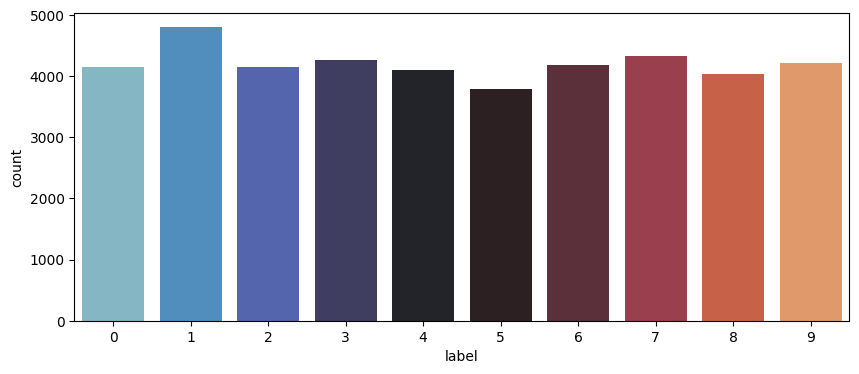

label
0    4143
1    4799
2    4147
3    4268
4    4099
5    3784
6    4180
7    4330
8    4040
9    4210
Name: count, dtype: int64

In [3]:
X_train = train.drop(columns="label")
Y_train = train["label"]

plt.figure(figsize=(10, 4))
sns.countplot(x=Y_train, palette="icefire")
plt.show()
Y_train.value_counts().sort_index()


The dataset is reasonably balanced because the empirical frequencies of the ten classes stay close to one another, so the empirical class prior
$$\hat p(Y=k)=\frac{n_k}{n}$$
does not concentrate on a small subset of digits. Consequently, no digit dominates the loss and accuracy remains a meaningful summary without class reweighting.

Q4: Plot 2 samples from the dataset.

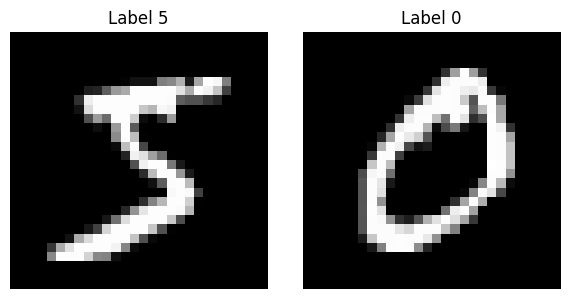

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

for ax, i in zip(axes, [0, 1]):
    ax.imshow(X_train.iloc[i].to_numpy().reshape(28, 28), cmap="gray")
    ax.set_title(f"Label {Y_train.iloc[i]}")
    ax.axis("off")

plt.tight_layout()


<a id="2"></a>
## Normalization, Reshape and Label Encoding
* Normalization
    * We perform a grayscale normalization to reduce the effect of illumination's differences.
    * If we perform normalization, CNN works faster.
* Reshape
    * Train and test images (28 x 28)
    * We reshape all data to 28x28x1 3D matrices.
    * Keras needs an extra dimension in the end which correspond to channels. Our images are gray scaled so it use only one channel.
* Label Encoding  
    * Encode labels to one hot vectors
        * 2 => [0,0,1,0,0,0,0,0,0,0]
        * 4 => [0,0,0,0,1,0,0,0,0,0]

Q5: Normalize the data by dividing each pixel by 255.

In [5]:
X_train = X_train.astype("float32") / 255.0


Q5: Explain how the reshape is performed in the cell below.

In [6]:
X_train = X_train.to_numpy().reshape(-1, 28, 28, 1)
print("x_train shape:", X_train.shape)


x_train shape: (42000, 28, 28, 1)


Each observation is initially a vector in
$$\mathbb{R}^{784}$$
obtained by stacking the grayscale image row by row, where the original image size is
$$28 \times 28.$$
The transformation `reshape(-1, 28, 28, 1)` reorganizes the same values into a tensor of shape `(n, 28, 28, 1)`, where `n` is inferred automatically, the middle dimensions are the spatial coordinates, and the last dimension is the unique grayscale channel. Since
$$784 = 28 \times 28,$$
no information is created or lost; only the arrangement of the same pixels is changed.

Q6: Perfom label encoding, this is done using to_categorical function that takes the initial labels and the total number of classes as parameters.

In [7]:
from tensorflow.keras.utils import to_categorical

Y_train = to_categorical(Y_train, num_classes=10)


<a id="3"></a>
Q7:  split the data into train and test sets. (fix random_state=2)
* test size is 10%.
* train size is 90%.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X_train,
    Y_train,
    test_size=0.1,
    random_state=2,
    stratify=Y_train.argmax(1),
)

print("x_train shape", X_train.shape)
print("x_test shape", X_val.shape)
print("y_train shape", Y_train.shape)
print("y_test shape", Y_val.shape)


x_train shape (37800, 28, 28, 1)
x_test shape (4200, 28, 28, 1)
y_train shape (37800, 10)
y_test shape (4200, 10)


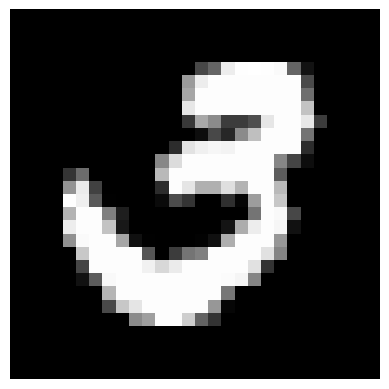

In [9]:
plt.imshow(X_train[2, :, :, 0], cmap="gray")
plt.axis("off")
plt.show()


<a id="4"></a>
## Convolutional Neural Network
* CNN is used for image classification, object detection
* <a href="https://ibb.co/kV1j9p"><img src="https://preview.ibb.co/nRkBpp/gec2.jpg" alt="gec2" border="0"></a>

<a id="5"></a>
### What is Convolution Operation?
* We have some image and feature detector(3*3)
* Feature detector does not need to be 3 by 3 matrix. It can be 5 by 5 or 7 by 7.
* Feature detector = kernel = filter
* Feauture detector detects features like edges or convex shapes. Example, if out input is dog, feature detector can detect features like ear or tail of the dog.
* feature map = conv(input image, feature detector). Element wise multiplication of matrices.
* feature map = convolved feature
* Stride = navigating in input image.
* We reduce the size of image. This is important bc code runs faster. However, we lost information.
* We create multiple feature maps bc we use multiple feature detectors(filters).
* Lets look at gimp. Edge detect: [0,10,0],[10,-4,10],[0,10,0]
* <a href="https://imgbb.com/"><img src="https://image.ibb.co/m4FQC9/gec.jpg" alt="gec" border="0"></a>
* After having convolution layer we use ReLU to break up linearity. Increase nonlinearity. Because images are non linear.
* <a href="https://ibb.co/mVZih9"><img src="https://preview.ibb.co/gbcQvU/RELU.jpg" alt="RELU" border="0"></a>

<a id="6"></a>
### Same Padding
* As we keep applying conv layers, the size of the volume will decrease faster than we would like. In the early layers of our network, we want to preserve as much information about the original input volume so that we can extract those low level features.
* input size and output size are same.
* <a href="https://ibb.co/jUPkUp"><img src="https://preview.ibb.co/noH5Up/padding.jpg" alt="padding" border="0"></a>

<a id="7"></a>
### Max Pooling
* It makes down-sampling or sub-sampling (Reduces the number of parameters)
* It makes the detection of features invariant to scale or orientation changes.
* It reduce the amount of parameters and computation in the network, and hence to also control overfitting.
* <a href="https://ibb.co/ckTjN9"><img src="https://preview.ibb.co/gsNYFU/maxpool.jpg" alt="maxpool" border="0"></a>

<a id="8"></a>
### Flattening
* <a href="https://imgbb.com/"><img src="https://image.ibb.co/c7eVvU/flattenigng.jpg" alt="flattenigng" border="0"></a>

<a id="9"></a>
### Full Connection
* Neurons in a fully connected layer have connections to all activations in the previous layer
* Artificial Neural Network
* <a href="https://ibb.co/hsS14p"><img src="https://preview.ibb.co/evzsAU/fullyc.jpg" alt="fullyc" border="0"></a>

<a id="10"></a>
## Implementing with Keras

<a id="11"></a>
### Create Model
* conv => max pool => dropout => conv => max pool => dropout => fully connected (2 layer)
* Dropout: Dropout is a technique where randomly selected neurons are ignored during training
* <a href="https://ibb.co/jGcvVU"><img src="https://preview.ibb.co/e7yPPp/dropout.jpg" alt="dropout" border="0"></a>

In [10]:
from sklearn.metrics import confusion_matrix


In [11]:
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPool2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Q8: Refer to this https://keras.io/guides/sequential_model/ to build your sequentail model.

*   For every convolution layer Conv2D you have to define the number of filters? the kernel size, the parameter padding='Same', the activation which is the relu for all;


*   Each convolution layer is followed by a pooling layer 2x2; For the seconf layer only, apply a stride window 2x2, meaning the pooling window moves 2 steps at a time, downsampling the feature map more aggressively.


*  Use dropout model.add(Dropout(0.25))  meaning that during training, 25% of the neurons in the previous layer (before this Dropout layer) will be randomly set to zero in each training iteration.The remaining 75% of neurons will stay active






In [12]:
model = Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    Conv2D(32, (5, 5), padding="same", activation="relu"),
    MaxPool2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPool2D((2, 2), strides=(2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax"),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 824,970 (3.15 MB)

 Trainable params: 824,970 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

We define the optimizer with the learning rate.

In [13]:
optimizer = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)


<a id="13"></a>
### Compile Model
* categorical crossentropy

* <a href="https://ibb.co/jm1bpp"><img src="https://preview.ibb.co/nN3ZaU/cce.jpg" alt="cce" border="0"></a>


Q9: Compile the model using model.compile, choose the predefined optimizer, the "categprical_crossentropy", and the accuracy as metrics.

In [14]:
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])


<a id="14"></a>
### Epochs and Batch Size
* Say you have a dataset of 10 examples (or samples). You have a **batch size** of 2, and you've specified you want the algorithm to run for 3 **epochs**. Therefore, in each epoch, you have 5 **batches** (10/2 = 5). Each batch gets passed through the algorithm, therefore you have 5 iterations **per epoch**.
* reference: https://stackoverflow.com/questions/4752626/epoch-vs-iteration-when-training-neural-networks

In [15]:
epochs = 10
batch_size = 250


<a id="15"></a>
### Data Augmentation
* To avoid overfitting problem, we need to expand artificially our handwritten digit dataset
* Alter the training data with small transformations to reproduce the variations of digit.
* For example, the number is not centered The scale is not the same (some who write with big/small numbers) The image is rotated.
* <a href="https://ibb.co/k24CUp"><img src="https://preview.ibb.co/nMxXUp/augment.jpg" alt="augment" border="0"></a>
    


In [16]:
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)

datagen.fit(X_train)


<a id="16"></a>
### Fit the model

Q10: Fit the model and explain the pertinence of each parameter.

In [17]:
history = model.fit(
    datagen.flow(X_train, Y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(X_val, Y_val),
    steps_per_epoch=X_train.shape[0] // batch_size,
    verbose=2,
)


Epoch 1/10


151/151 - 21s - 140ms/step - accuracy: 0.7599 - loss: 0.7341 - val_accuracy: 0.9633 - val_loss: 0.1187


Epoch 2/10


151/151 - 1s - 7ms/step - accuracy: 0.9000 - loss: 0.3283 - val_accuracy: 0.9626 - val_loss: 0.1192


Epoch 3/10


...

151/151 - 1s - 7ms/step - accuracy: 0.9400 - loss: 0.1770 - val_accuracy: 0.9812 - val_loss: 0.0608


Epoch 9/10


151/151 - 19s - 124ms/step - accuracy: 0.9602 - loss: 0.1285 - val_accuracy: 0.9810 - val_loss: 0.0591


Epoch 10/10


151/151 - 1s - 5ms/step - accuracy: 0.9680 - loss: 0.1016 - val_accuracy: 0.9826 - val_loss: 0.0584


The generator `datagen.flow(X_train, Y_train, batch_size=batch_size)` produces mini-batches of augmented observations, so each gradient step is computed on transformed versions of the training images rather than on repeated exact copies. The parameter `batch_size` fixes the number of observations used in each stochastic approximation of the gradient, `epochs` fixes the number of complete passes through the training stream, and `validation_data=(X_val, Y_val)` evaluates out-of-sample performance on untouched data after each epoch. Finally,
$$\mathrm{steps\_per\_epoch}=\left\lfloor \frac{n_{\mathrm{train}}}{\mathrm{batch\_size}} \right\rfloor$$
makes one epoch correspond approximately to one full pass over the training set.

Q11: Plot the test loss.

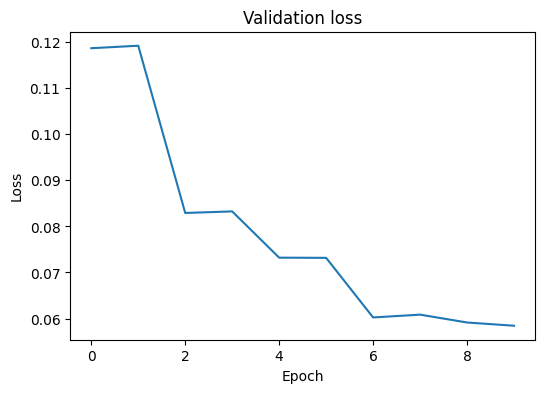

In [18]:
plt.figure(figsize=(6, 4))
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation loss")
plt.show()


The notebook sets aside a validation set rather than a separate test set, so the relevant out-of-sample loss available during training is the validation loss. It is the empirical categorical cross-entropy computed on data that are excluded from the gradient updates.

Q12: Visualize the confusion matrix.

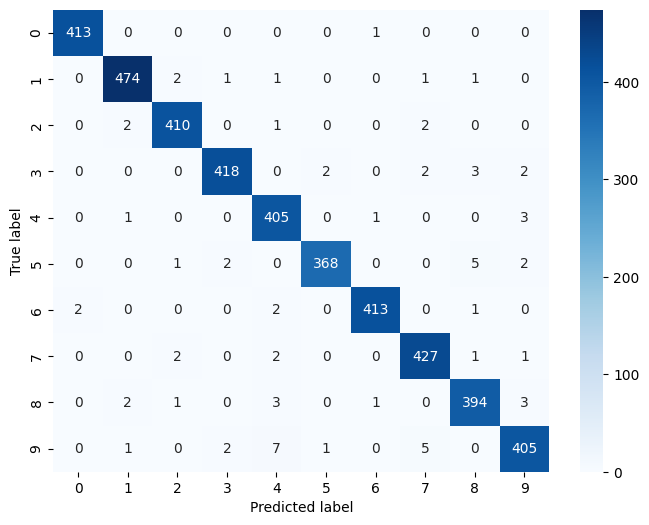

In [19]:
Y_pred = model.predict(X_val, verbose=0).argmax(1)
Y_true = Y_val.argmax(1)
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()
